In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

[0.         0.12693304 0.25386607 0.38079911 0.50773215 0.63466518
 0.76159822 0.88853126 1.01546429 1.14239733]
[0.         0.25645654 0.51291309 0.76936963 1.02582617 1.28228272
 1.53873926 1.7951958  2.05165235 2.30810889]


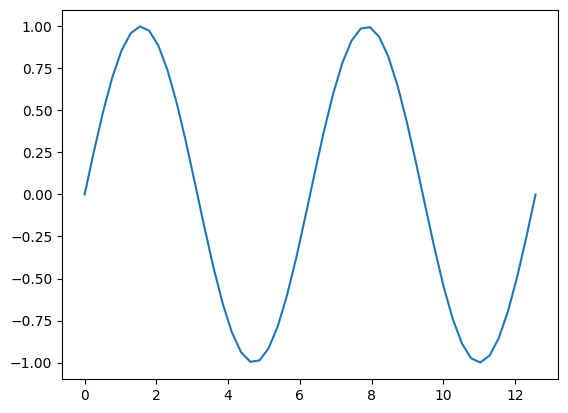

In [2]:
x_train= np.linspace(0,4*np.pi, 100)
y_train= torch.from_numpy(np.sin(x_train))

x_test= np.linspace(0,4*np.pi, 50)
y_test= torch.from_numpy(np.sin(x_test))


print(x_train[:10])
print(x_test[:10])

plt.subplot(1,1,1)
plt.plot(x_test,y_test)

### Question:
we do generate test data with diffrent points to avoid overfit the network
        

In [3]:
torch.manual_seed(42)
# Layer 1
w_l1 = torch.rand((1, 64))
b_l1 = torch.rand((64,))

# Layer 2
w_l2 = torch.rand((64, 64))
b_l2 = torch.rand((64,))

# Layer 3
w_l3 = torch.rand((64,))
b_l3 = torch.rand(())

params = [w_l1, b_l1, w_l2, b_l2, w_l3, b_l3]
for param in params:
    param.requires_grad = True

In [17]:
def forward(input):
    x = torch.tensor([[input]])  # Shape: (1, 1)

    # Layer 1: (1, 1) @ (1, 64) --> (1, 64)
    x = torch.relu(x @ w_l1 + b_l1)

    # Layer 2: (1, 64) @ (64, 64) --> (1, 64)
    x = torch.relu(x @ w_l2 + b_l2)

    # Layer 3: (1, 64) @ (64,) --> (1,)
    x = x @ w_l3 + b_l3

    return x.squeeze()

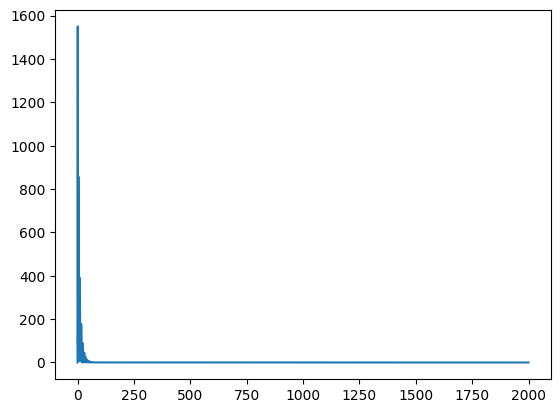

In [14]:
# training loop
epochs = 2000
pred = torch.zeros(len(y_train))
optim = torch.optim.Adam(params,lr=0.01)
epochs_his =[]
loss_his   =[]
for epoch in range(epochs):
    optim.zero_grad()
    # pred = torch.tensor([forward(float(x)) for x in x_test])
    pred = torch.stack([forward(float(x)) for x in x_train])

    loss = torch.mean((pred-y_train)**2)

    loss.backward()

    optim.step()

    # print("epoch {} || loss {} ".format(epoch, loss))
    # with torch.no_grad():
    epochs_his.append(epoch)
    loss_his.append(loss.item())

plt.subplot()
plt.plot(epochs_his,loss_his)


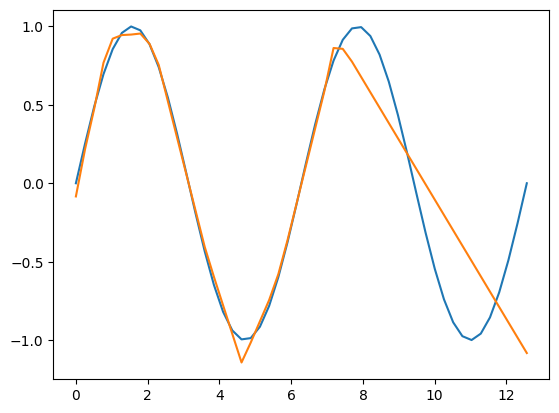

In [15]:
with torch.no_grad():
    y_pred_test =  torch.tensor([forward(float(x)) for x in x_test])
    plt.subplot()
    plt.plot(x_test,y_test)
    plt.plot(x_test,y_pred_test.numpy())
    # print(y_test)
    # print(y_pred_test)

## Qsts
* Q1: the gradient presents the dervative of the output with respect to a specific param, becasue the gradient presents the how much the increase of this prameter increase the loss so we go inverse of the gradient.
* Q2: the loss.backward() do propagate the grad calculation starting from the loss through all the network, so caluclate all the parameters gradients.
  - forward: calculate the ouput of the network for a specfic input
  - compute loss: calculate how much is the difference between prediction and real correct value
  - backward: calculate the gradient for each parameters
  - optimizer.step: evalutes gradient decents to modify the network params.


In [19]:
with torch.no_grad():
    final_pred = torch.stack([forward(float(x)) for x in x_test])
    final_loss = torch.mean((final_pred - y_test)**2)
    print(f"Final test MSE: {final_loss.item():.6f}")

Final test MSE: 0.082208
